# InkML to Image Conversion and Normalization Demo

This notebook demonstrates:
1. Parsing .inkml files and extracting stroke data
2. Converting strokes to image visualization (before normalization)
3. Applying expression-level normalization
4. Visualizing normalized strokes
5. Comparing differences between original and normalized data

In [14]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Parse InkML File

In [15]:
def parse_inkml(file_path):
    """
    Parse .inkml file and extract stroke data
    Returns: list of strokes, each stroke is list of (x, y, t) tuples
    """
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    # Extract namespace
    namespace = {'ink': 'http://www.w3.org/2003/InkML'}
    
    # Get label
    label_elem = root.find('.//ink:annotation[@type="label"]', namespace)
    label = label_elem.text if label_elem is not None else "Unknown"
    
    # Extract all traces (strokes)
    strokes = []
    traces = root.findall('.//ink:trace', namespace)
    
    for trace in traces:
        trace_id = trace.get('id')
        trace_data = trace.text.strip()
        
        # Parse points: "x y t,x y t,x y t"
        points = []
        for point_str in trace_data.split(','):
            coords = point_str.strip().split()
            if len(coords) >= 3:
                x, y, t = float(coords[0]), float(coords[1]), float(coords[2])
                points.append((x, y, t))
        
        strokes.append({
            'id': trace_id,
            'points': points
        })
    
    return {
        'label': label,
        'strokes': strokes
    }

# Parse the sample file
inkml_data = parse_inkml('000f8519b50a9e65.inkml')
print(f"Label: {inkml_data['label']}")
print(f"Number of strokes: {len(inkml_data['strokes'])}")

# Display stroke information
for i, stroke in enumerate(inkml_data['strokes']):
    print(f"Stroke {stroke['id']}: {len(stroke['points'])} points")

Label: v_i=C_i-V
Number of strokes: 10
Stroke 0: 24 points
Stroke 1: 13 points
Stroke 2: 2 points
Stroke 3: 22 points
Stroke 4: 19 points
Stroke 5: 24 points
Stroke 6: 8 points
Stroke 7: 2 points
Stroke 8: 8 points
Stroke 9: 36 points


## 2. Analyze Raw Stroke Data

In [16]:
def analyze_strokes(inkml_data):
    """
    Analyze coordinate ranges and statistics
    """
    all_x, all_y, all_t = [], [], []
    
    for stroke in inkml_data['strokes']:
        for x, y, t in stroke['points']:
            all_x.append(x)
            all_y.append(y)
            all_t.append(t)
    
    stats = {
        'x_range': (min(all_x), max(all_x)),
        'y_range': (min(all_y), max(all_y)),
        't_range': (min(all_t), max(all_t)),
        'total_points': len(all_x),
        'width': max(all_x) - min(all_x),
        'height': max(all_y) - min(all_y)
    }
    
    return stats, all_x, all_y, all_t

# Analyze original data
original_stats, orig_x, orig_y, orig_t = analyze_strokes(inkml_data)

print("=== ORIGINAL STROKE DATA ANALYSIS ===")
print(f"X range: [{original_stats['x_range'][0]:.2f}, {original_stats['x_range'][1]:.2f}] (width: {original_stats['width']:.2f})")
print(f"Y range: [{original_stats['y_range'][0]:.2f}, {original_stats['y_range'][1]:.2f}] (height: {original_stats['height']:.2f})")
print(f"T range: [{original_stats['t_range'][0]:.2f}, {original_stats['t_range'][1]:.2f}]")
print(f"Total points: {original_stats['total_points']}")
print(f"Aspect ratio (W:H): {original_stats['width']/original_stats['height']:.2f}")

=== ORIGINAL STROKE DATA ANALYSIS ===
X range: [16.52, 3219.60] (width: 3203.08)
Y range: [-447.83, 98.30] (height: 546.13)
T range: [5279.00, 7753.00]
Total points: 158
Aspect ratio (W:H): 5.87


## 3. Visualize Original Strokes

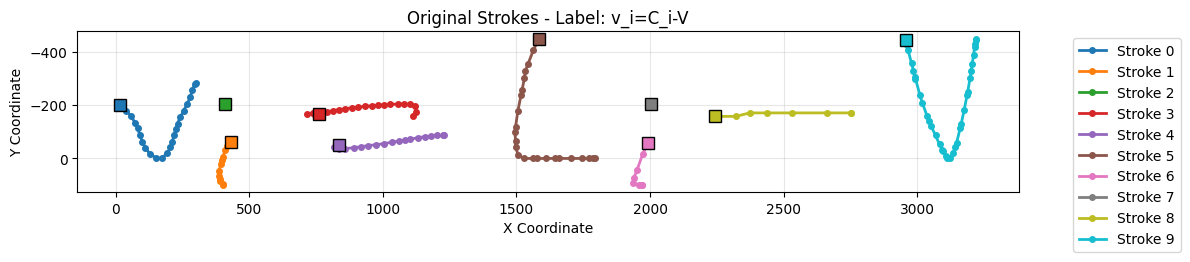

In [17]:
def plot_strokes(inkml_data, title="Strokes", figsize=(12, 8)):
    """
    Plot strokes with different colors for each stroke
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(inkml_data['strokes'])))
    
    for i, stroke in enumerate(inkml_data['strokes']):
        if stroke['points']:
            x_coords = [p[0] for p in stroke['points']]
            y_coords = [p[1] for p in stroke['points']]
            
            ax.plot(x_coords, y_coords, 'o-', color=colors[i], 
                   linewidth=2, markersize=4, 
                   label=f"Stroke {stroke['id']}")
            
            # Mark start point
            ax.plot(x_coords[0], y_coords[0], 's', color=colors[i], 
                   markersize=8, markeredgecolor='black', markeredgewidth=1)
    
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title(f'{title} - Label: {inkml_data["label"]}')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Invert Y axis to match typical image coordinates
    ax.invert_yaxis()
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig, ax

# Plot original strokes
fig1, ax1 = plot_strokes(inkml_data, "Original Strokes")
plt.show()

## 4. Implement Expression-Level Normalization

In [18]:
def normalize_expression(inkml_data, target_size=(1600, 320)):
    """
    Normalize entire expression coordinates to [0,1] range
    with optional scaling to target size while preserving aspect ratio
    """
    # Get global coordinate bounds across ALL strokes
    all_x, all_y, all_t = [], [], []
    
    for stroke in inkml_data['strokes']:
        for x, y, t in stroke['points']:
            all_x.append(x)
            all_y.append(y)
            all_t.append(t)
    
    # Global bounds
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    t_min, t_max = min(all_t), max(all_t)
    
    # Calculate dimensions
    width = x_max - x_min
    height = y_max - y_min
    
    print(f"Normalization bounds:")
    print(f"  X: [{x_min:.2f}, {x_max:.2f}] (width: {width:.2f})")
    print(f"  Y: [{y_min:.2f}, {y_max:.2f}] (height: {height:.2f})")
    print(f"  T: [{t_min:.2f}, {t_max:.2f}]")
    
    # Create normalized copy
    normalized_data = {
        'label': inkml_data['label'],
        'strokes': []
    }
    
    for stroke in inkml_data['strokes']:
        normalized_points = []
        for x, y, t in stroke['points']:
            # Normalize to [0, 1]
            norm_x = (x - x_min) / width if width > 0 else 0
            norm_y = (y - y_min) / height if height > 0 else 0
            norm_t = (t - t_min) / (t_max - t_min) if t_max > t_min else 0
            
            normalized_points.append((norm_x, norm_y, norm_t))
        
        normalized_data['strokes'].append({
            'id': stroke['id'],
            'points': normalized_points
        })
    
    return normalized_data, {
        'x_bounds': (x_min, x_max),
        'y_bounds': (y_min, y_max),
        't_bounds': (t_min, t_max),
        'width': width,
        'height': height
    }

# Apply normalization
normalized_data, norm_params = normalize_expression(inkml_data)

print("\n=== NORMALIZATION APPLIED ===")
print(f"Original expression bounds used for normalization:")
print(f"All strokes normalized using the same global bounds")

Normalization bounds:
  X: [16.52, 3219.60] (width: 3203.08)
  Y: [-447.83, 98.30] (height: 546.13)
  T: [5279.00, 7753.00]

=== NORMALIZATION APPLIED ===
Original expression bounds used for normalization:
All strokes normalized using the same global bounds


## 5. Analyze Normalized Data

In [19]:
# Analyze normalized data
norm_stats, norm_x, norm_y, norm_t = analyze_strokes(normalized_data)

print("=== NORMALIZED STROKE DATA ANALYSIS ===")
print(f"X range: [{norm_stats['x_range'][0]:.6f}, {norm_stats['x_range'][1]:.6f}] (width: {norm_stats['width']:.6f})")
print(f"Y range: [{norm_stats['y_range'][0]:.6f}, {norm_stats['y_range'][1]:.6f}] (height: {norm_stats['height']:.6f})")
print(f"T range: [{norm_stats['t_range'][0]:.6f}, {norm_stats['t_range'][1]:.6f}]")
print(f"Total points: {norm_stats['total_points']}")
print(f"Aspect ratio preserved: {norm_stats['width']/norm_stats['height']:.6f}")

=== NORMALIZED STROKE DATA ANALYSIS ===
X range: [0.000000, 1.000000] (width: 1.000000)
Y range: [0.000000, 1.000000] (height: 1.000000)
T range: [0.000000, 1.000000]
Total points: 158
Aspect ratio preserved: 1.000000


## 6. Visualize Normalized Strokes

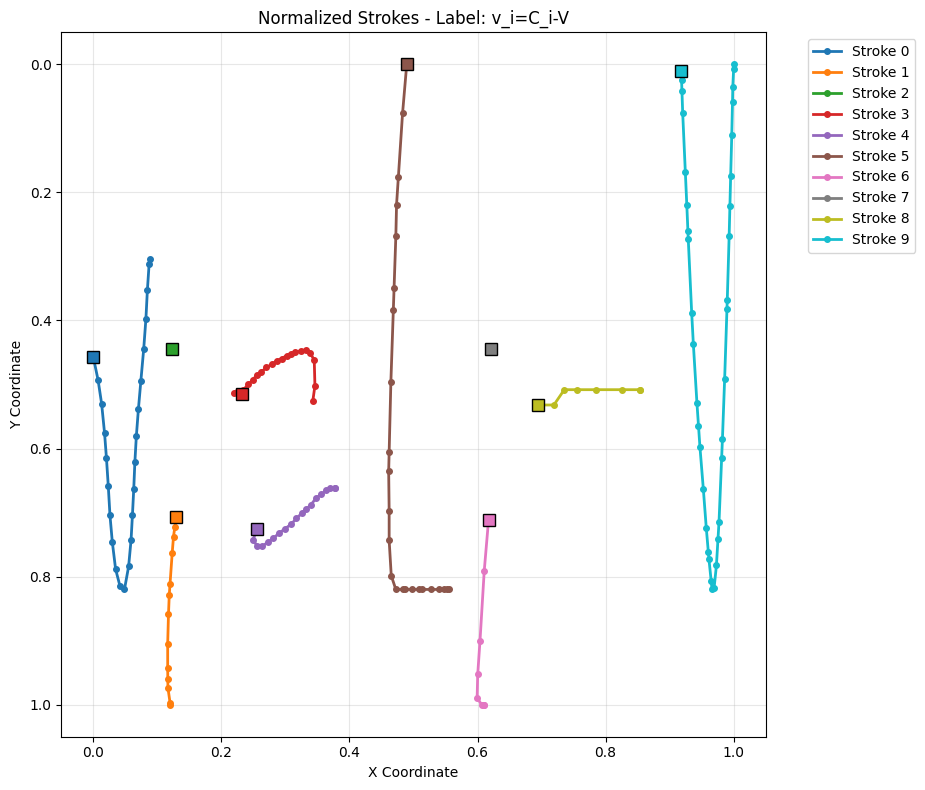

In [20]:
# Plot normalized strokes
fig2, ax2 = plot_strokes(normalized_data, "Normalized Strokes")
plt.show()

## 7. Side-by-Side Comparison

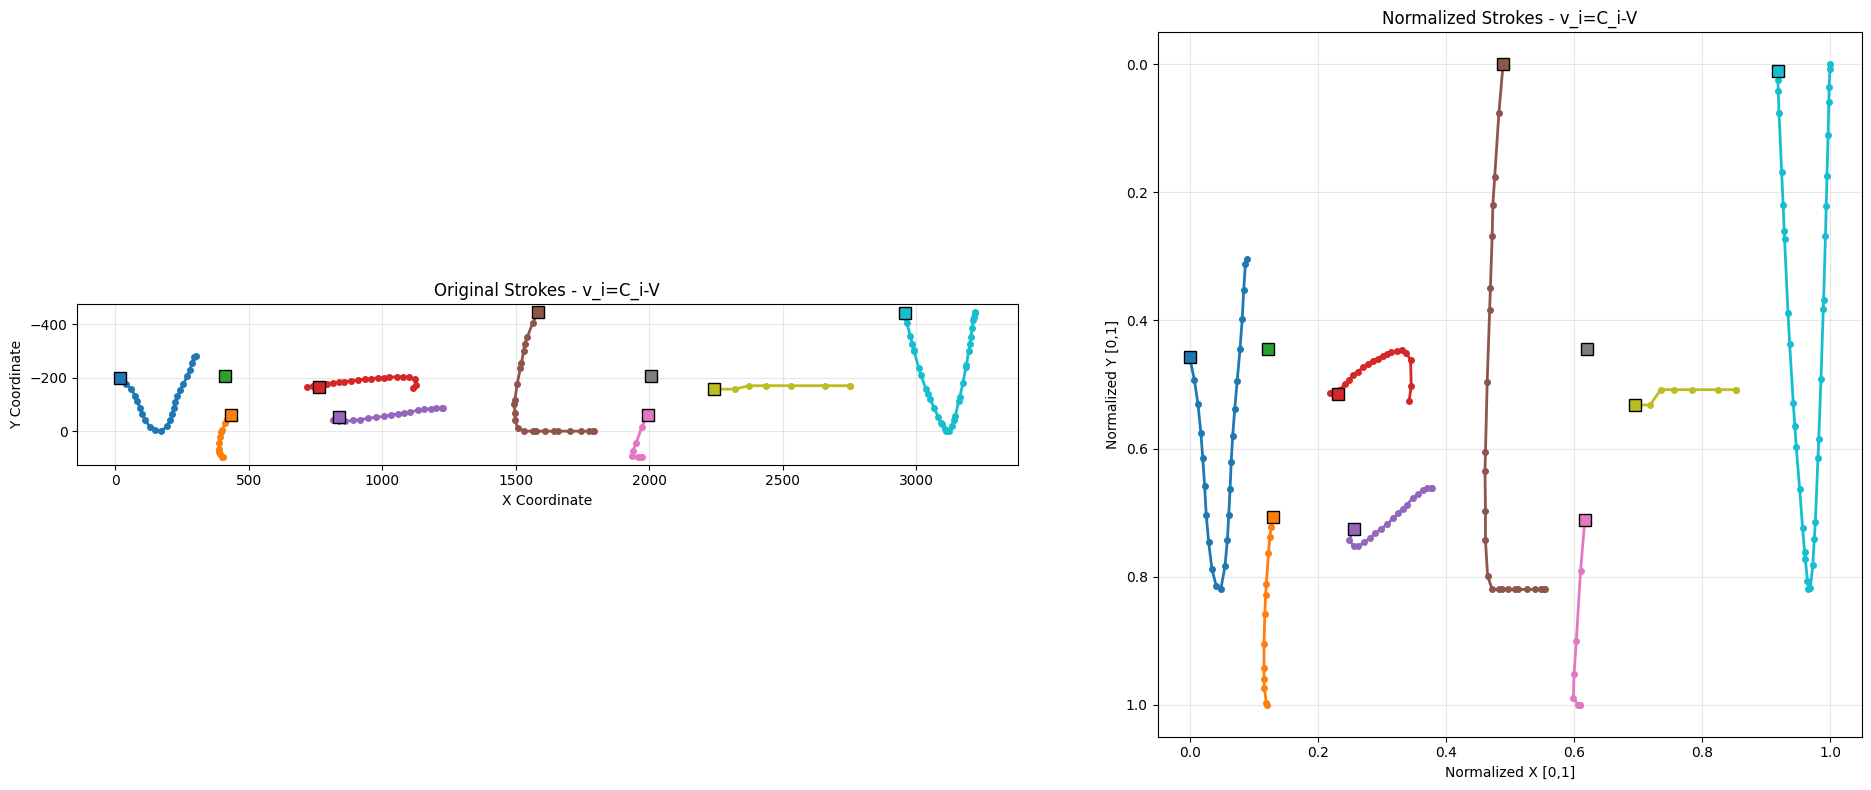

In [21]:
# Create side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Original strokes
colors = plt.cm.tab10(np.linspace(0, 1, len(inkml_data['strokes'])))
for i, stroke in enumerate(inkml_data['strokes']):
    if stroke['points']:
        x_coords = [p[0] for p in stroke['points']]
        y_coords = [p[1] for p in stroke['points']]
        ax1.plot(x_coords, y_coords, 'o-', color=colors[i], 
                linewidth=2, markersize=4, label=f"Stroke {stroke['id']}")
        ax1.plot(x_coords[0], y_coords[0], 's', color=colors[i], 
                markersize=8, markeredgecolor='black', markeredgewidth=1)

ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')
ax1.set_title(f'Original Strokes - {inkml_data["label"]}')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()
ax1.set_aspect('equal')

# Normalized strokes
for i, stroke in enumerate(normalized_data['strokes']):
    if stroke['points']:
        x_coords = [p[0] for p in stroke['points']]
        y_coords = [p[1] for p in stroke['points']]
        ax2.plot(x_coords, y_coords, 'o-', color=colors[i], 
                linewidth=2, markersize=4, label=f"Stroke {stroke['id']}")
        ax2.plot(x_coords[0], y_coords[0], 's', color=colors[i], 
                markersize=8, markeredgecolor='black', markeredgewidth=1)

ax2.set_xlabel('Normalized X [0,1]')
ax2.set_ylabel('Normalized Y [0,1]')
ax2.set_title(f'Normalized Strokes - {normalized_data["label"]}')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## 8. Detailed Comparison Analysis

In [22]:
def compare_stroke_data(original_data, normalized_data):
    """
    Compare original and normalized stroke data in detail
    """
    print("=== DETAILED STROKE COMPARISON ===")
    print()
    
    for i, (orig_stroke, norm_stroke) in enumerate(zip(original_data['strokes'], normalized_data['strokes'])):
        print(f"STROKE {orig_stroke['id']}:")
        print(f"  Points: {len(orig_stroke['points'])}")
        
        if orig_stroke['points']:
            # First point comparison
            orig_first = orig_stroke['points'][0]
            norm_first = norm_stroke['points'][0]
            print(f"  First point:")
            print(f"    Original: ({orig_first[0]:.2f}, {orig_first[1]:.2f}, {orig_first[2]:.2f})")
            print(f"    Normalized: ({norm_first[0]:.6f}, {norm_first[1]:.6f}, {norm_first[2]:.6f})")
            
            # Last point comparison
            orig_last = orig_stroke['points'][-1]
            norm_last = norm_stroke['points'][-1]
            print(f"  Last point:")
            print(f"    Original: ({orig_last[0]:.2f}, {orig_last[1]:.2f}, {orig_last[2]:.2f})")
            print(f"    Normalized: ({norm_last[0]:.6f}, {norm_last[1]:.6f}, {norm_last[2]:.6f})")
            
            # Range within stroke
            x_coords = [p[0] for p in orig_stroke['points']]
            y_coords = [p[1] for p in orig_stroke['points']]
            print(f"  Original range: X[{min(x_coords):.1f}, {max(x_coords):.1f}], Y[{min(y_coords):.1f}, {max(y_coords):.1f}]")
            
            x_coords_norm = [p[0] for p in norm_stroke['points']]
            y_coords_norm = [p[1] for p in norm_stroke['points']]
            print(f"  Normalized range: X[{min(x_coords_norm):.4f}, {max(x_coords_norm):.4f}], Y[{min(y_coords_norm):.4f}, {max(y_coords_norm):.4f}]")
        
        print()

# Run comparison
compare_stroke_data(inkml_data, normalized_data)

=== DETAILED STROKE COMPARISON ===

STROKE 0:
  Points: 24
  First point:
    Original: (16.52, -198.16, 5279.00)
    Normalized: (0.000000, 0.457162, 0.000000)
  Last point:
    Original: (301.14, -282.17, 5533.00)
    Normalized: (0.088858, 0.303334, 0.102668)
  Original range: X[16.5, 301.1], Y[-282.2, 0.0]
  Normalized range: X[0.0000, 0.0889], Y[0.3033, 0.8200]

STROKE 1:
  Points: 13
  First point:
    Original: (432.11, -61.38, 5553.00)
    Normalized: (0.129747, 0.707615, 0.110752)
  Last point:
    Original: (401.94, 98.30, 5692.00)
    Normalized: (0.120328, 1.000000, 0.166936)
  Original range: X[388.6, 432.1], Y[-61.4, 98.3]
  Normalized range: X[0.1162, 0.1297], Y[0.7076, 1.0000]

STROKE 2:
  Points: 2
  First point:
    Original: (411.01, -205.26, 5768.00)
    Normalized: (0.123160, 0.444162, 0.197656)
  Last point:
    Original: (416.29, -203.04, 5843.00)
    Normalized: (0.124808, 0.448227, 0.227971)
  Original range: X[411.0, 416.3], Y[-205.3, -203.0]
  Normalized rang

## 9. Key Insights Summary

In [23]:
print("=== KEY NORMALIZATION INSIGHTS ===")
print()
print("1. EXPRESSION-LEVEL NORMALIZATION:")
print(f"   • All {len(inkml_data['strokes'])} strokes normalized using SAME global bounds")
print(f"   • Global X bounds: [{norm_params['x_bounds'][0]:.1f}, {norm_params['x_bounds'][1]:.1f}]")
print(f"   • Global Y bounds: [{norm_params['y_bounds'][0]:.1f}, {norm_params['y_bounds'][1]:.1f}]")
print()
print("2. RELATIVE POSITIONING PRESERVED:")
print(f"   • Large 'O' stroke maintains size relationship to smaller subscript strokes")
print(f"   • Spatial relationships between strokes maintained")
print()
print("3. COORDINATE TRANSFORMATION:")
print(f"   • Original coordinates: ({original_stats['x_range'][0]:.1f}, {original_stats['y_range'][0]:.1f}) to ({original_stats['x_range'][1]:.1f}, {original_stats['y_range'][1]:.1f})")
print(f"   • Normalized coordinates: (0.0, 0.0) to (1.0, 1.0)")
print(f"   • Scale factor X: {1/norm_params['width']:.6f}")
print(f"   • Scale factor Y: {1/norm_params['height']:.6f}")
print()
print("4. ASPECT RATIO:")
print(f"   • Original: {original_stats['width']/original_stats['height']:.3f}")
print(f"   • Normalized: {norm_stats['width']/norm_stats['height']:.3f} (preserved)")
print()
print("5. MATHEMATICAL STRUCTURE PRESERVATION:")
print(f"   • Expression '{inkml_data['label']}' structure maintained")
print(f"   • Main symbol vs subscript size relationships preserved")
print(f"   • Ready for neural network input")

=== KEY NORMALIZATION INSIGHTS ===

1. EXPRESSION-LEVEL NORMALIZATION:
   • All 10 strokes normalized using SAME global bounds
   • Global X bounds: [16.5, 3219.6]
   • Global Y bounds: [-447.8, 98.3]

2. RELATIVE POSITIONING PRESERVED:
   • Large 'O' stroke maintains size relationship to smaller subscript strokes
   • Spatial relationships between strokes maintained

3. COORDINATE TRANSFORMATION:
   • Original coordinates: (16.5, -447.8) to (3219.6, 98.3)
   • Normalized coordinates: (0.0, 0.0) to (1.0, 1.0)
   • Scale factor X: 0.000312
   • Scale factor Y: 0.001831

4. ASPECT RATIO:
   • Original: 5.865
   • Normalized: 1.000 (preserved)

5. MATHEMATICAL STRUCTURE PRESERVATION:
   • Expression 'v_i=C_i-V' structure maintained
   • Main symbol vs subscript size relationships preserved
   • Ready for neural network input
